In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split

# Création de données  (2 classes)
X, y = make_moons(n_samples=300, noise=0.2, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Modèle très complexe (trop de neurones)
overfit_model = Sequential([
    Dense(500, activation='relu', input_shape=(2,)),
    Dense(500, activation='relu'),
    Dense(500, activation='relu'),
    Dense(1, activation='sigmoid')
])

overfit_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

history = overfit_model.fit(X_train, y_train,
                           epochs=200,
                           validation_data=(X_test, y_test),
                           verbose=1)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 61ms/step - accuracy: 0.7714 - loss: 0.5298 - val_accuracy: 0.9000 - val_loss: 0.3004
Epoch 2/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.8381 - loss: 0.3386 - val_accuracy: 0.8889 - val_loss: 0.2533
Epoch 3/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.8476 - loss: 0.3194 - val_accuracy: 0.9111 - val_loss: 0.2214
Epoch 4/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.8429 - loss: 0.3039 - val_accuracy: 0.9000 - val_loss: 0.2307
Epoch 5/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.8619 - loss: 0.2819 - val_accuracy: 0.9000 - val_loss: 0.2360
Epoch 6/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.8714 - loss: 0.2679 - val_accuracy: 0.8889 - val_loss: 0.2055
Epoch 7/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.8714 - loss: 0.2526 - val_accuracy: 0.8778 - val_loss: 0.2323
Epoch 8/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.9000 - loss: 0.2299 - val_accuracy: 0.8889 - val_loss:

5172/5172 ━━━━━━━━━━━━━━━━━━━━ 18s 4ms/step


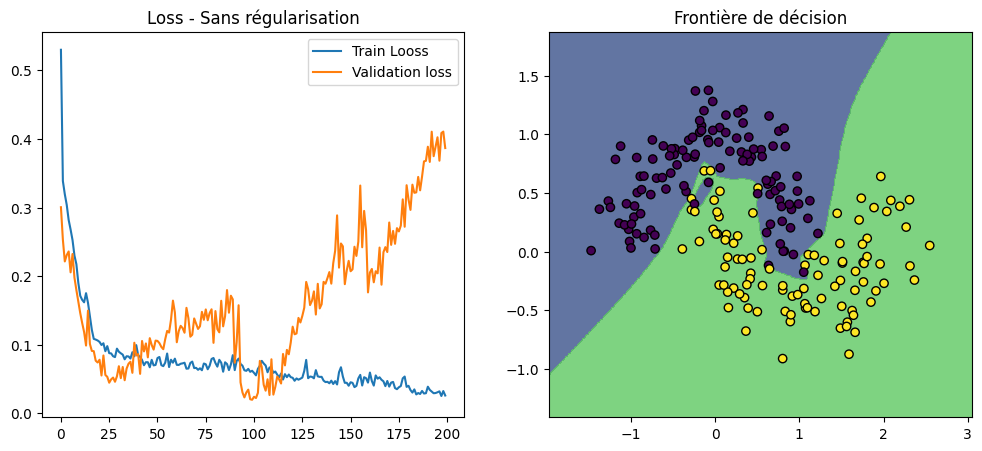

In [ ]:
# Courbes d'apprentissage
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Looss')
plt.plot(history.history['val_loss'], label='Validation loss')
plt.title('Loss - Sans régularisation')
plt.legend()

# Frontière de décision
def plot_decision_boundary(model, X, y):
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    h = 0.01
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]) > 0.5
    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.8)
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k')
    plt.title("Frontière de décision")

plt.subplot(1, 2, 2)
plot_decision_boundary(overfit_model, X_train, y_train)
plt.show()

In [ ]:
from tensorflow.keras.regularizers import l2

# Même architecture mais avec régularisation L2
regularized_model = Sequential([
    Dense(500, activation='relu', input_shape=(2,), kernel_regularizer=l2(0.01)),
    Dense(500, activation='relu', kernel_regularizer=l2(0.01)),
    Dense(500, activation='relu', kernel_regularizer=l2(0.01)),
    Dense(1, activation='sigmoid')
])

regularized_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

reg_history = regularized_model.fit(X_train, y_train,
                                   epochs=200,
                                   validation_data=(X_test, y_test),
                                   verbose=0)

5172/5172 ━━━━━━━━━━━━━━━━━━━━ 18s 3ms/step


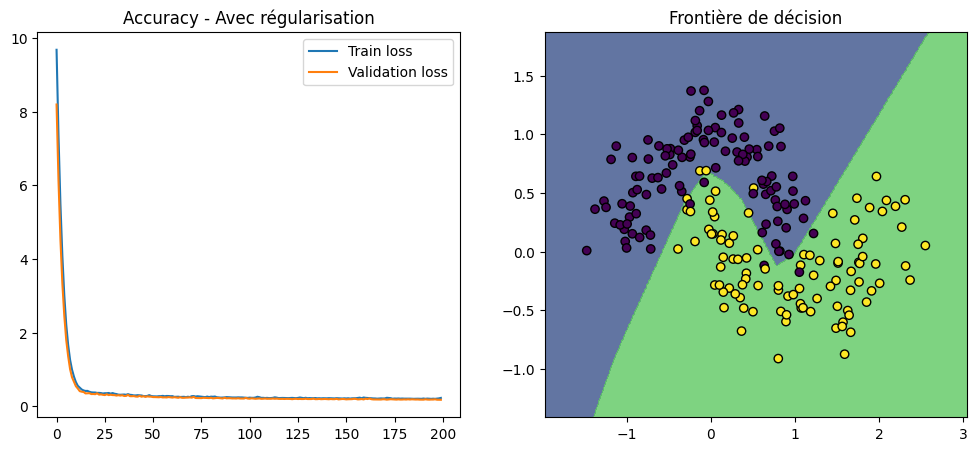

In [ ]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(reg_history.history['loss'], label='Train loss')
plt.plot(reg_history.history['val_loss'], label='Validation loss')
plt.title('Accuracy - Avec régularisation')
plt.legend()

plt.subplot(1, 2, 2)
plot_decision_boundary(regularized_model, X_train, y_train)
plt.show()

5172/5172 ━━━━━━━━━━━━━━━━━━━━ 18s 4ms/step
5172/5172 ━━━━━━━━━━━━━━━━━━━━ 19s 4ms/step


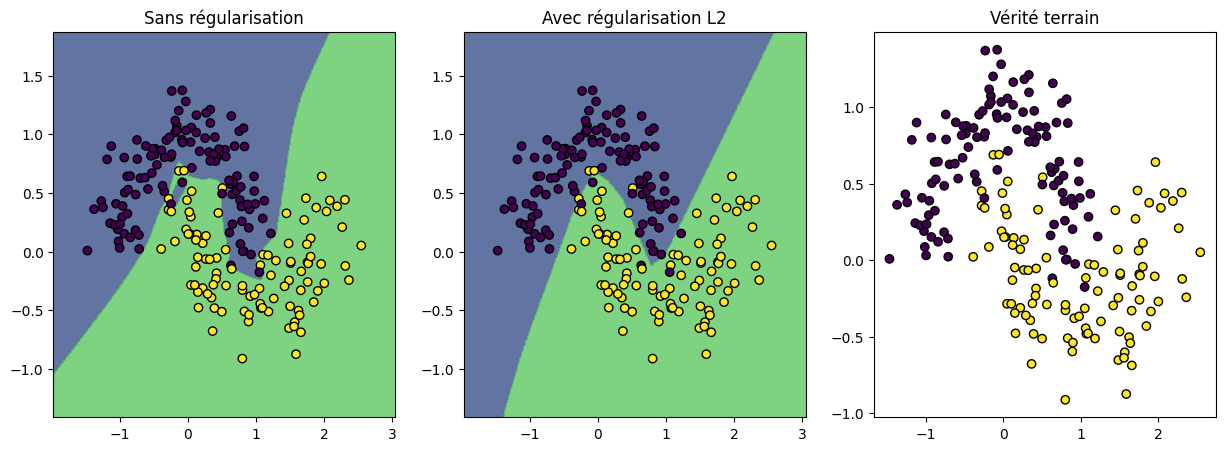

In [ ]:
plt.figure(figsize=(15, 5))

# Sans régularisation
plt.subplot(1, 3, 1)
plot_decision_boundary(overfit_model, X_train, y_train)
plt.title("Sans régularisation")

# Avec régularisation
plt.subplot(1, 3, 2)
plot_decision_boundary(regularized_model, X_train, y_train)
plt.title("Avec régularisation L2")

# Vérité terrain
plt.subplot(1, 3, 3)
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, edgecolors='k')
plt.title("Vérité terrain")
plt.show()

### To DO
Dans le notebook Regularisation.ipynb, tu as déjà implémenté un modèle sur-paramétré (3 couches de 500 neurones) et tu as appliqué une régularisation L2 (kernel_regularizer=l2(0.01)).
Je souhaite que tu complètes ce TP en testant également :

La régularisation L1 (lasso)

La régularisation L1 + L2 (ElasticNet)

### Travail à réaliser
#### 1. Créer deux nouveaux modèles
Copie la structure du modèle regularized_model et remplace la régularisation :

Modèle avec L1 : utilise kernel_regularizer=l1(0.01)

Modèle avec ElasticNet : utilise kernel_regularizer=l1_l2(l1=0.01, l2=0.01)

N'oublie pas d'importer les régulariseurs correspondants :

python
``from tensorflow.keras.regularizers import l1, l1_l2``
#### 2. Entraîner chaque modèle
Entraîne-les sur les mêmes données (X_train, y_train) avec les mêmes paramètres :

epochs = 200

validation_data = (X_test, y_test)

verbose = 0 (pour ne pas polluer la sortie)

Stocke leurs historiques (history_l1, history_elastic).

#### 3. Visualiser les courbes d’apprentissage et les frontières de décision
Pour chaque modèle, produit une figure similaire à celle que tu as déjà utilisée pour L2 :

À gauche : évolution de la loss (train et validation)

À droite : frontière de décision sur les données d’entraînement

#### 4. Comparaison finale
Génère une figure avec 4 sous‑figures (ou deux figures côte à côte) :

Sans régularisation (modèle overfit)

Avec L2

Avec L1

Avec ElasticNet

Ajoute également un titre explicatif sur l’effet observé (par exemple : L1 rend la frontière plus simple, L2 plus lisse, ElasticNet un compromis).

In [11]:
from tensorflow.keras.regularizers import l1, l1_l2

# Modèle avec régularisation L1
l1_model = Sequential([
    Dense(500, activation='relu', input_shape=(2,), kernel_regularizer=l1(0.01)),
    Dense(500, activation='relu', kernel_regularizer=l1(0.01)),
    Dense(500, activation='relu', kernel_regularizer=l1(0.01)),
    Dense(1, activation='sigmoid')
])
l1_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
history_l1 = l1_model.fit(X_train, y_train,
                           epochs=200,
                           validation_data=(X_test, y_test),
                           verbose=0)

# Modèle avec régularisation ElasticNet (L1 + L2)
elastic_model = Sequential([
    Dense(500, activation='relu', input_shape=(2,), kernel_regularizer=l1_l2(l1=0.01, l2=0.01)),
    Dense(500, activation='relu', kernel_regularizer=l1_l2(l1=0.01, l2=0.01)),
    Dense(500, activation='relu', kernel_regularizer=l1_l2(l1=0.01, l2=0.01)),
    Dense(1, activation='sigmoid')
])
elastic_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
history_elastic = elastic_model.fit(X_train, y_train,
                                    epochs=200,
                                    validation_data=(X_test, y_test),
                                    verbose=0)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


5172/5172 ━━━━━━━━━━━━━━━━━━━━ 26s 5ms/step


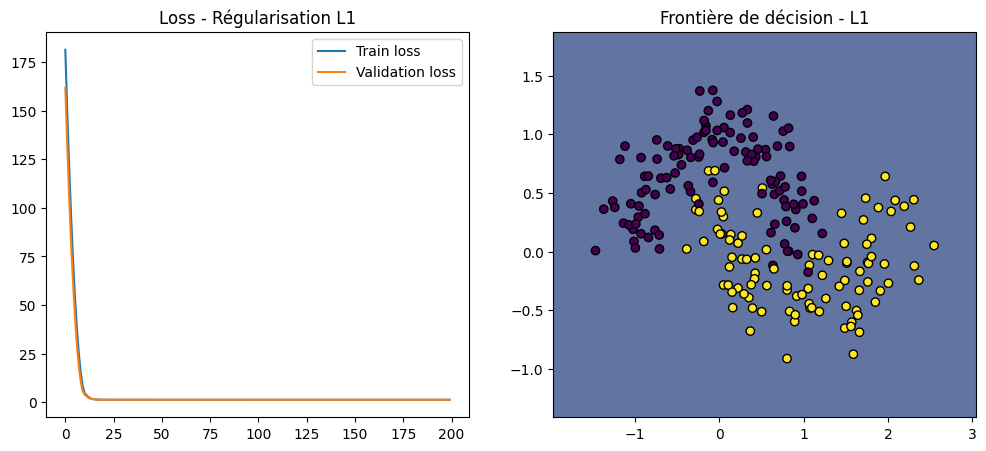

In [12]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history_l1.history['loss'], label='Train loss')
plt.plot(history_l1.history['val_loss'], label='Validation loss')
plt.title('Loss - Régularisation L1')
plt.legend()

plt.subplot(1, 2, 2)
plot_decision_boundary(l1_model, X_train, y_train)
plt.title("Frontière de décision - L1")
plt.show()

5172/5172 ━━━━━━━━━━━━━━━━━━━━ 22s 4ms/step


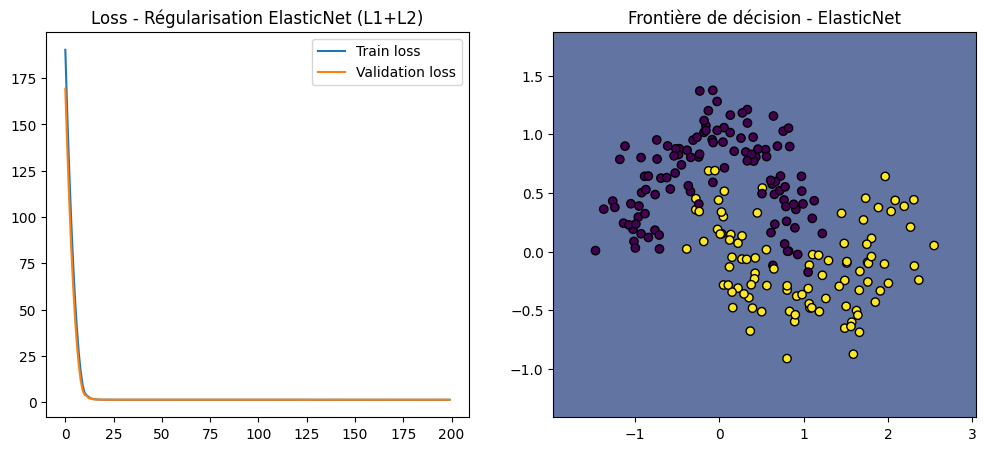

In [13]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history_elastic.history['loss'], label='Train loss')
plt.plot(history_elastic.history['val_loss'], label='Validation loss')
plt.title('Loss - Régularisation ElasticNet (L1+L2)')
plt.legend()

plt.subplot(1, 2, 2)
plot_decision_boundary(elastic_model, X_train, y_train)
plt.title("Frontière de décision - ElasticNet")
plt.show()

5172/5172 ━━━━━━━━━━━━━━━━━━━━ 22s 4ms/step
5172/5172 ━━━━━━━━━━━━━━━━━━━━ 22s 4ms/step
5172/5172 ━━━━━━━━━━━━━━━━━━━━ 20s 4ms/step
5172/5172 ━━━━━━━━━━━━━━━━━━━━ 20s 4ms/step


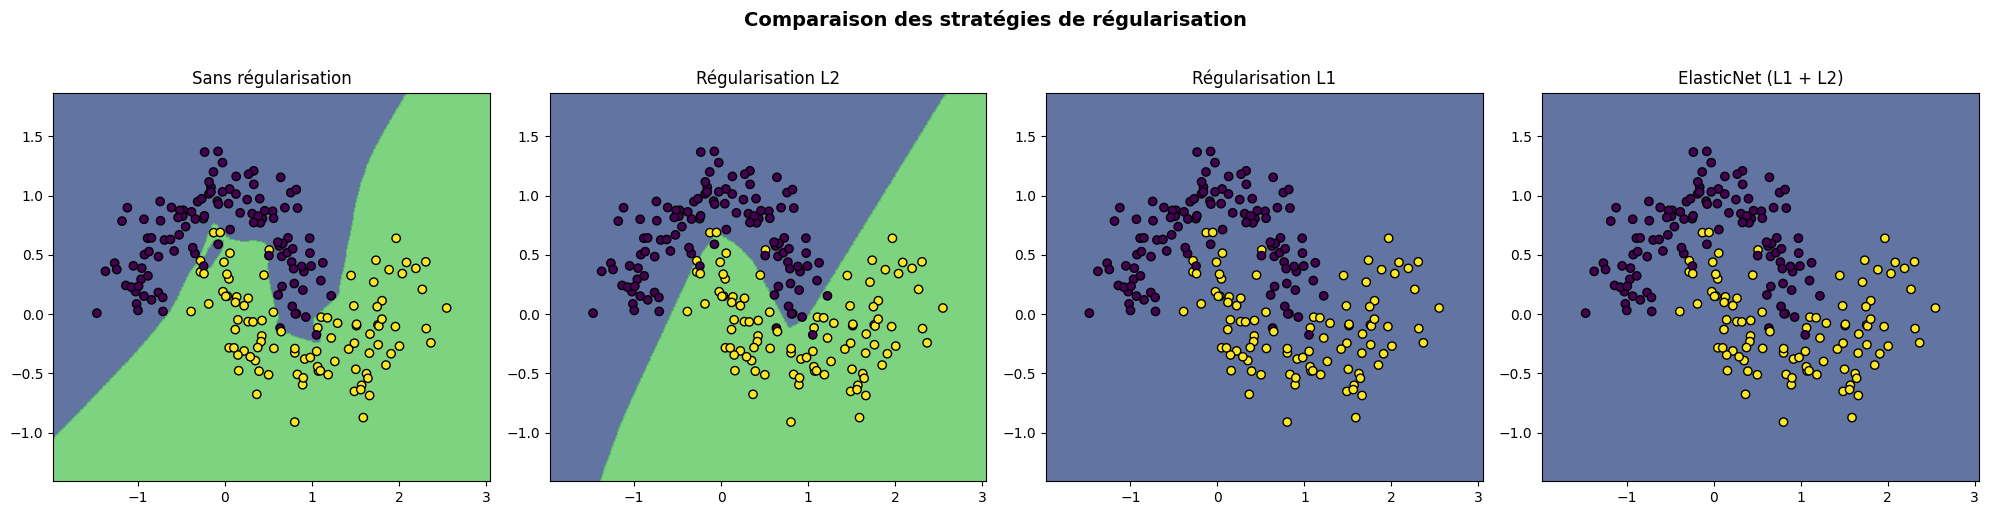

In [14]:
plt.figure(figsize=(20, 5))

plt.subplot(1, 4, 1)
plot_decision_boundary(overfit_model, X_train, y_train)
plt.title("Sans régularisation")

plt.subplot(1, 4, 2)
plot_decision_boundary(regularized_model, X_train, y_train)
plt.title("Régularisation L2")

plt.subplot(1, 4, 3)
plot_decision_boundary(l1_model, X_train, y_train)
plt.title("Régularisation L1")

plt.subplot(1, 4, 4)
plot_decision_boundary(elastic_model, X_train, y_train)
plt.title("ElasticNet (L1 + L2)")

plt.suptitle("Comparaison des stratégies de régularisation", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()